In [ ]:
# Mount Google Drive and set up project environment
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/DATA6545/"
PROJECT_PATH = BASE_PATH + "allstate_project/"
DATA_PATH = PROJECT_PATH + "data/raw/"

# Load raw train and test CSVs from Drive
TRAIN_PATH = DATA_PATH + "train.csv"
TEST_PATH = DATA_PATH + "test.csv"
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
# Confirm shapes
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Mounted at /content/drive
Train shape: (188318, 132)
Test shape: (125546, 131)


,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,1,A,B,A,B,A,A,A,A,B,...,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,2,A,B,A,A,A,A,A,A,B,...,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,5,A,B,A,A,B,A,A,A,B,...,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,10,B,B,A,B,A,A,A,A,B,...,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,11,A,B,A,B,A,A,A,A,B,...,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


In [ ]:
# Inspect data
train.info()
train.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188318 entries, 0 to 188317
Columns: 132 entries, id to loss
dtypes: float64(15), int64(1), object(116)
memory usage: 189.7+ MB


,0
id,0
cat1,0
cat2,0
cat3,0
cat4,0
cat5,0
cat6,0
cat7,0
cat8,0
cat9,0


In [ ]:
# Seperate target from features
target = "loss"
feature_cols = [c for c in train.columns if c != target]

# 'Cat' = categorical, 'cont' = continuous
cat_cols = [c for c in feature_cols if c.startswith("cat")]
num_cols = [c for c in feature_cols if c.startswith("cont")]

print("Total features:", len(feature_cols))
print("Categorical features:", len(cat_cols))
print("Numeric features:", len(num_cols))

Total features: 131
Categorical features: 116
Numeric features: 14


In [ ]:
# Summary Statistics from the raw laoss target
# Note heavy right skew
train[target].describe()

,loss
count,188318.000000
mean,3037.337686
std,2904.086186
min,0.670000
25%,1204.460000
50%,2115.570000
75%,3864.045000
max,121012.250000


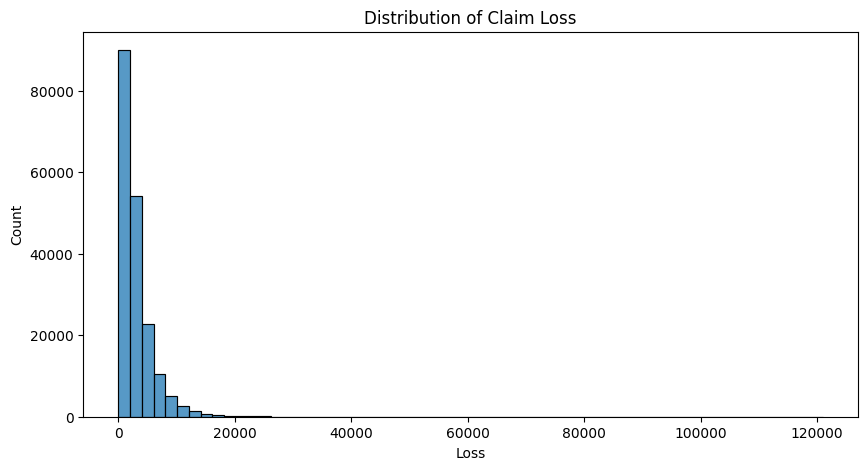

In [ ]:
# Visualize raw loss distributions - confirm heavy right skew
plt.figure(figsize=(10,5))
sns.histplot(train["loss"], bins=60)
plt.title("Distribution of Claim Loss")
plt.xlabel("Loss")
plt.ylabel("Count")
plt.show()

In [ ]:
# Apply log1p transformation to stabilize variance and reduce skew
train["log_loss"] = np.log1p(train["loss"])

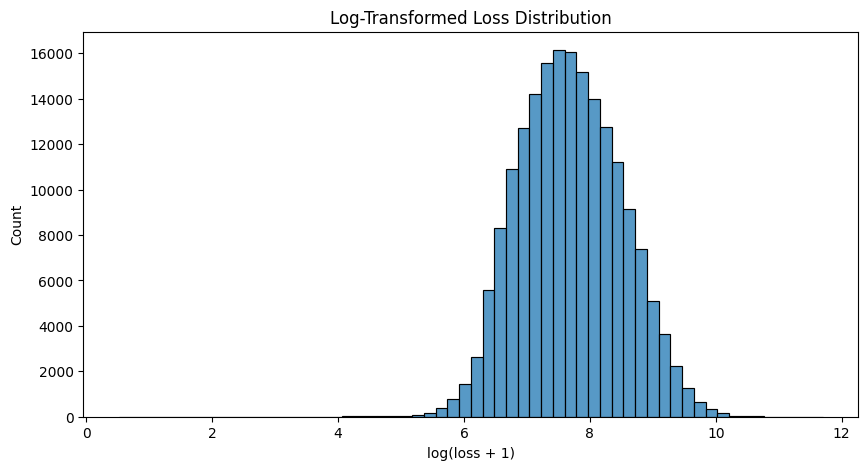

In [ ]:
# Log-transformed target is approx. normal, better suited for regression
plt.figure(figsize=(10,5))
sns.histplot(train["log_loss"], bins=60)
plt.title("Log-Transformed Loss Distribution")
plt.xlabel("log(loss + 1)")
plt.ylabel("Count")
plt.show()

In [ ]:
# EDA: Continuous Feature Correlations with Loss
# Pearson correlation of each continuous feature against raw loss
cont_corr = train[num_cols + ["loss"]].corr()["loss"].drop("loss").sort_values()

plt.figure(figsize=(8, 5))
cont_corr.plot(kind="barh", color="steelblue")
plt.title("Continuous Feature Correlations with Loss")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/cont_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

# EDA: Categorical Feature Cardinality
# How many unique values does each categorical feature have?
cardinality = train[cat_cols].nunique().sort_values(ascending=False)

plt.figure(figsize=(14, 4))
cardinality.plot(kind="bar", color="steelblue")
plt.title("Unique Values per Categorical Feature (Cardinality)")
plt.xlabel("Feature")
plt.ylabel("Unique Values")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/cat_cardinality.png", dpi=150, bbox_inches="tight")
plt.show()

print("High cardinality features (>10 unique values):")
print(cardinality[cardinality > 10])

In [ ]:
# EDA: Outlier Analysis
# Claims above $20,000 are statistical outliers and may hurt model performance
outlier_threshold = 20000
n_outliers = (train["loss"] > outlier_threshold).sum()
pct_outliers = n_outliers / len(train) * 100

print(f"Claims above ${outlier_threshold:,}: {n_outliers} ({pct_outliers:.2f}% of data)")
print(f"Mean loss (all):        ${train['loss'].mean():,.2f}")
print(f"Mean loss (excl. outliers): ${train[train['loss'] <= outlier_threshold]['loss'].mean():,.2f}")

# Boxplot to visualize spread
plt.figure(figsize=(8, 4))
train["loss"].clip(upper=20000).plot(kind="box", vert=False)
plt.title("Loss Distribution (clipped at $20,000 for visibility)")
plt.xlabel("Loss ($)")
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/loss_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Define feature matrix and log-transformed target vector
y = train["log_loss"]
X = train[feature_cols]

In [ ]:
# Import splitting utility
from sklearn.model_selection import train_test_split

In [ ]:
# 80/20 stratified split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Verify split proportions
print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])

Training rows: 150654
Validation rows: 37664


In [ ]:
# Sklearn pipeline components
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
# Numeric pipeline - median imputation and standard scaling
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
# Categorical pipeline - mode imputation and one-hot encoding
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
# Combine numeric and categorical pipelines into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [ ]:
# Evaluation metrics
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Baseline model: ridge regression inside a full preprocessing and model pipeline
# Ridge adds L2 regularization which helps with the high-cardinality one-hot encoding features
ridge_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [ ]:
# Train baseline Ridge model on training set
ridge_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['cont1', 'cont2', 'cont3',
                                                   'cont4', 'cont5', 'cont6',
                                                   'cont7', 'cont8', 'cont9',
                                                   'cont10', 'cont11', 'cont12',
                                                   'cont13', 'cont14']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cat1', 'cat2', 'cat3',
                                                   'cat4', 'cat5', 'cat6',
                                                   'cat7', 'cat8', 'cat9',
                                                   'cat10', 'cat11', 'cat12',
                                                   'cat13', 'cat14', 'cat15',
                                                   'cat16', 'cat17', 'cat18',
                                                   'cat19', 'cat20', 'cat21',
                                                   'cat22', 'cat23', 'cat24',
                                                   'cat25', 'cat26', 'cat27',
                                                   'cat28', 'cat29', 'cat30', ...])])),
                ('model', Ridge())])

In [ ]:
# Generate validation predicitons - still in log scale
ridge_pred_log = ridge_model.predict(X_valid)

In [ ]:
# Inverse log1p transform to get predictions back in dollars
ridge_pred = np.expm1(ridge_pred_log)
y_valid_actual = np.expm1(y_valid)

In [ ]:
# Evaluate Ridge baseline
ridge_mae = mean_absolute_error(y_valid_actual, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_valid_actual, ridge_pred))
ridge_r2 = r2_score(y_valid_actual, ridge_pred)

print("Ridge MAE:", round(ridge_mae, 2))
print("Ridge RMSE:", round(ridge_rmse, 2))
print("Ridge R2:", round(ridge_r2, 4))

Ridge MAE: 1244.68
Ridge RMSE: 2185.06
Ridge R2: 0.4149


In [ ]:
# Import Random Forest
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# RF configured with dept limit of 12 to avoid extreme overfitting
# n_estimators = 150 to balance performance vs. training time on 188k rows
rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        max_depth=12,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
# Train Random Forest
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['cont1', 'cont2', 'cont3',
                                                   'cont4', 'cont5', 'cont6',
                                                   'cont7', 'cont8', 'cont9',
                                                   'cont10', 'cont11', 'cont12',
                                                   'cont13', 'cont14']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequen...
                                                  ['cat1', 'cat2', 'cat3',
                                                   'cat4', 'cat5', 'cat6',
                                                   'cat7', 'cat8', 'cat9',
                                                   'cat10', 'cat11', 'cat12',
                                                   'cat13', 'cat14', 'cat15',
                                                   'cat16', 'cat17', 'cat18',
                                                   'cat19', 'cat20', 'cat21',
                                                   'cat22', 'cat23', 'cat24',
                                                   'cat25', 'cat26', 'cat27',
                                                   'cat28', 'cat29', 'cat30', ...])])),
                ('model',
                 RandomForestRegressor(max_depth=12, min_samples_split=10,
                                       n_estimators=150, n_jobs=-1,
                                       random_state=42))])

In [ ]:
# Predict of validation set (log scale)
rf_pred_log = rf_model.predict(X_valid)

In [ ]:
# Back to dollar scale for evaluation
rf_pred = np.expm1(rf_pred_log)

In [ ]:
# Random Forest Results
rf_mae = mean_absolute_error(y_valid_actual, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_valid_actual, rf_pred))
rf_r2 = r2_score(y_valid_actual, rf_pred)

print("Random Forest MAE:", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest R2:", round(rf_r2, 4))

Random Forest MAE: 1223.44
Random Forest RMSE: 2055.23
Random Forest R2: 0.4823


In [ ]:
# Comparing Ridge Regression and Random Forest
results = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest"],
    "MAE": [ridge_mae, rf_mae],
    "RMSE": [ridge_rmse, rf_rmse],
    "R2": [ridge_r2, rf_r2]
})

results.sort_values("MAE")

,Model,MAE,RMSE,R2
1,Random Forest,1223.438710,2055.227342,0.482333
0,Ridge Regression,1244.678849,2185.063748,0.414861


In [ ]:
# Import KFold cross-validation
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
# 5-fold CV with shuffle
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Manual loop instead of cross_val_score to capture per-fold metrics
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

cv = KFold(n_splits=5, shuffle=True, random_state=42)

fold_maes = []
fold_rmses = []
fold_r2s = []
fold_train_maes = []
fold_mapes = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    t0 = time.time()

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    m = clone(rf_model)
    m.fit(X_tr, y_tr)

    val_preds_log = m.predict(X_val)
    train_preds_log = m.predict(X_tr)

    val_preds = np.expm1(val_preds_log)
    train_preds = np.expm1(train_preds_log)
    y_val_true = np.expm1(y_val)
    y_tr_true = np.expm1(y_tr)

    val_mae = mean_absolute_error(y_val_true, val_preds)
    val_rmse = np.sqrt(mean_squared_error(y_val_true, val_preds))
    val_r2 = r2_score(y_val_true, val_preds)
    train_mae = mean_absolute_error(y_tr_true, train_preds)
    mape = np.mean(np.abs((y_val_true - val_preds) / (y_val_true + 1e-8))) * 100

    fold_maes.append(val_mae)
    fold_rmses.append(val_rmse)
    fold_r2s.append(val_r2)
    fold_train_maes.append(train_mae)
    fold_mapes.append(mape)

    print(f"Fold {fold+1} | val MAE: {val_mae:.2f}  RMSE: {val_rmse:.2f}  "
          f"R2: {val_r2:.4f}  MAPE: {mape:.2f}%  "
          f"train MAE: {train_mae:.2f}  ({(time.time()-t0)/60:.1f} min)")

print(f"\nMean CV MAE:  {np.mean(fold_maes):.2f} +/- {np.std(fold_maes):.2f}")
print(f"Mean CV RMSE: {np.mean(fold_rmses):.2f} +/- {np.std(fold_rmses):.2f}")
print(f"Mean CV R2:   {np.mean(fold_r2s):.4f} +/- {np.std(fold_r2s):.4f}")
print(f"Mean MAPE:    {np.mean(fold_mapes):.2f}%")
print(f"\nMean train MAE: {np.mean(fold_train_maes):.2f}")
print(f"Overfit gap (train vs val MAE): {np.mean(fold_maes) - np.mean(fold_train_maes):.2f}")

print(f"\nHoldout MAE was {rf_mae:.2f}, CV mean is {np.mean(fold_maes):.2f}")

Fold 1 | val MAE: 1222.66  RMSE: 2058.67  R2: 0.4806  MAPE: 51.97%  train MAE: 1159.99  (71.0 min)
Fold 2 | val MAE: 1245.27  RMSE: 2111.71  R2: 0.4659  MAPE: 59.89%  train MAE: 1151.86  (69.0 min)
Fold 3 | val MAE: 1242.42  RMSE: 2110.21  R2: 0.4749  MAPE: 53.26%  train MAE: 1154.50  (72.9 min)
Fold 4 | val MAE: 1243.25  RMSE: 2159.66  R2: 0.4711  MAPE: 52.80%  train MAE: 1155.84  (70.7 min)
Fold 5 | val MAE: 1230.28  RMSE: 2135.77  R2: 0.4542  MAPE: 52.36%  train MAE: 1156.98  (73.8 min)

Mean CV MAE:  1236.78 +/- 8.80
Mean CV RMSE: 2115.21 +/- 33.56
Mean CV R2:   0.4694 +/- 0.0090
Mean MAPE:    54.05%

Mean train MAE: 1155.83
Overfit gap (train vs val MAE): 80.94

Holdout MAE was 1223.44, CV mean is 1236.78


In [ ]:
# Summarize cross-validation results
cv_scores = np.array(fold_maes)
print("CV MAE:", cv_scores.mean())
print("CV Std:", cv_scores.std())

CV MAE: 1236.7764049630532
CV Std: 8.802390949188592


In [ ]:
# Final Baseline Model Summary
summary = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest (holdout)", "Random Forest (CV mean)"],
    "MAE": [1244.68, 1223.44, cv_scores.mean()],
    "RMSE": [2185.06, 2055.23, None],
    "R2": [0.4149, 0.4823, np.mean(fold_r2s)],
    "CV Std (MAE)": [None, None, cv_scores.std()]
}).round(4)

print(summary.to_string(index=False))
print("\nConclusion: Random Forest outperforms Ridge on all metrics.")
print("CV results confirm no significant overfitting (low fold variance).")